# 9 · Heating a room on a winter night

A smart thermostat should keep a room comfortable overnight with as little electricity as
possible, and all we have are logs from an old thermostat that heated harder on colder nights.
In those logs more heating goes with faster cooling, so a model fitted on them learns the wrong
lesson about the heater. We ask `chc` for tonight's plan with and without the weather, play both
plans on the real room, and read how far the library says each one can be trusted.

In [1]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

jax.config.update("jax_enable_x64", True)
jax.config.update("jax_platforms", "cpu")  # the outputs below were made on a CPU
%matplotlib inline

from chc import CausalGraph, Constraint, Driver, Lever, NotIdentifiedError, Panel, Target, prescribe

## 1 · The logs

**The room.** Newton's law of cooling says that a room loses heat to the outside in proportion
to the temperature difference. With a heater added, the law reads
`dT/dt = −k·(T − T_out) + b·u`, where:

- `T` is the room temperature and `T_out` the outdoor temperature, both in °C;
- `u` is the heater power in kilowatts (kW), and `t` is the time in hours;
- `k` says how fast the room leaks heat, and `b` says how many degrees per hour one kilowatt
  adds.

We use this law to simulate the room. `chc` is not told it: it must learn from the logs how the
room responds, above all the heater's effect `b`.

**The old thermostat.** It set the power mostly from the weather: the colder the night, the
more it heated. It added a little power when the room was cold, and its setting jittered a
little from hour to hour.

**The logs.** We simulate them. Then we know the true answer and can check every estimate
against it. Each night in each home is logged once an hour.

In [2]:
K = 0.05  # how fast the room leaks heat, per hour
B = 1.0  # what one kilowatt adds, in °C per hour
HEATER_MAX = 3.0  # kW
HOMES, NIGHTS, HOURS = 60, 4, 10  # each night is logged from 22:00, once an hour, for HOURS hours


def room_step(temperature, outdoor_start, outdoor_end, power, hours=1.0):
    """The room temperature after `hours` of Newton's law, solved exactly: the power is held and the
    outdoor temperature moves in a straight line from `outdoor_start` to `outdoor_end`."""
    slope = (outdoor_end - outdoor_start) / hours
    level = outdoor_start + (B * power - slope) / K
    return level + slope * hours + (temperature - level) * np.exp(-K * hours)


def old_thermostat(temperature, outdoor, rng):
    """The policy that wrote the logs: a weather curve, a little room feedback, some jitter."""
    power = (
        0.95 - 0.025 * outdoor + 0.05 * (19.0 - temperature) + rng.normal(0.0, 0.1, outdoor.shape)
    )
    return np.clip(power, 0.0, HEATER_MAX)


def simulate_logs(seed=0):
    rng = np.random.default_rng(seed)
    nights = HOMES * NIGHTS
    outdoor = np.empty((nights, HOURS + 1))
    level = rng.uniform(-15.0, 10.0, nights)  # how cold each night is
    wiggle = np.zeros(nights)
    for hour in range(HOURS + 1):
        wiggle = 0.8 * wiggle + rng.normal(0.0, 0.3, nights)
        outdoor[:, hour] = level + 1.5 - 0.3 * hour + wiggle  # colder towards dawn
    temperature = np.empty((nights, HOURS + 1))
    power = np.empty((nights, HOURS + 1))
    temperature[:, 0] = rng.normal(20.0, 1.0, nights)
    for hour in range(HOURS + 1):
        power[:, hour] = old_thermostat(temperature[:, hour], outdoor[:, hour], rng)
        if hour < HOURS:
            temperature[:, hour + 1] = room_step(
                temperature[:, hour], outdoor[:, hour], outdoor[:, hour + 1], power[:, hour]
            ) + rng.normal(0.0, 0.05, nights)  # draughts, doors, people: small random pushes
    night = np.repeat(np.arange(nights), HOURS + 1)
    return pd.DataFrame(
        {
            "home": night // NIGHTS,
            "night": night,  # one night in one home
            "hour": np.tile(np.arange(HOURS + 1), nights),  # hours since 22:00
            "temperature": temperature.ravel(),
            "heater": power.ravel(),
            "outdoor": outdoor.ravel(),
        }
    )


logs = simulate_logs()
print(
    f"{HOMES} homes × {NIGHTS} nights, logged once an hour from 22:00 to "
    f"{(22 + HOURS) % 24:02d}:00: {len(logs)} readings"
)
print(f"true values: k = {K} per hour, b = {B} °C per hour for each kW")
print(f"outdoor temperature in the logs: {logs.outdoor.min():.1f} to {logs.outdoor.max():.1f} °C")
logs.head().round(2)

60 homes × 4 nights, logged once an hour from 22:00 to 08:00: 2640 readings
true values: k = 0.05 per hour, b = 1.0 °C per hour for each kW
outdoor temperature in the logs: -16.9 to 11.7 °C


,home,night,hour,temperature,heater,outdoor
0,0,0,0,21.06,0.72,2.07
1,0,0,1,20.84,0.61,2.26
2,0,0,2,20.54,0.87,1.32
3,0,0,3,20.49,0.74,1.35
4,0,0,4,20.32,0.90,1.26


## 2 · The trap

Each dot below is one logged hour. It shows the heater power during that hour and how much the
room temperature changed by the end of it. The colour is the outdoor temperature. A heater
warms a room, so we expect the dots to rise to the right.

pooled slope of the logs: -0.21 °C over the hour for each extra kW
true effect of one kW over one hour: +0.98 °C


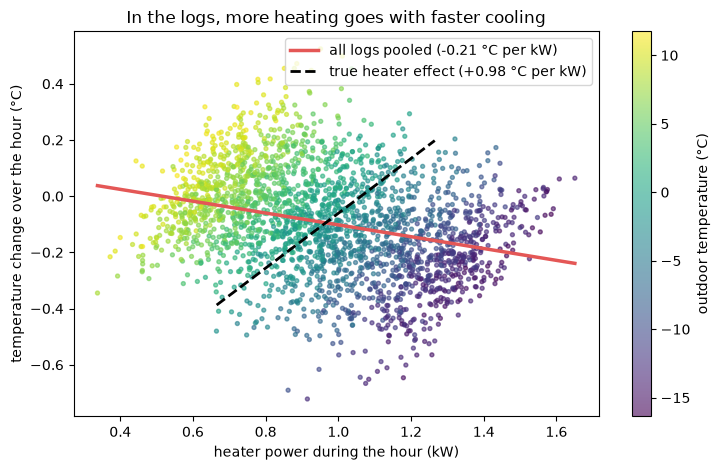

In [3]:
hourly = logs.assign(
    change=logs.groupby("night")["temperature"].shift(-1) - logs["temperature"]
).dropna()
slope, intercept = np.polyfit(hourly["heater"], hourly["change"], 1)
one_hour_effect = B * (1.0 - np.exp(-K)) / K  # one kW for one hour, less what leaks out meanwhile
print(f"pooled slope of the logs: {slope:+.2f} °C over the hour for each extra kW")
print(f"true effect of one kW over one hour: {one_hour_effect:+.2f} °C")

fig, ax = plt.subplots(figsize=(7.5, 4.8))
dots = ax.scatter(
    hourly["heater"], hourly["change"], c=hourly["outdoor"], cmap="viridis", s=8, alpha=0.6
)
span = np.linspace(hourly["heater"].min(), hourly["heater"].max(), 2)
ax.plot(
    span,
    intercept + slope * span,
    color="#E45756",
    lw=2.5,
    label=f"all logs pooled ({slope:+.2f} °C per kW)",
)
centre = hourly["heater"].mean(), hourly["change"].mean()
near = centre[0] + np.array([-0.3, 0.3])
ax.plot(
    near,
    centre[1] + one_hour_effect * (near - centre[0]),
    "k--",
    lw=2,
    label=f"true heater effect ({one_hour_effect:+.2f} °C per kW)",
)
ax.set_xlabel("heater power during the hour (kW)")
ax.set_ylabel("temperature change over the hour (°C)")
ax.set_title("In the logs, more heating goes with faster cooling")
fig.colorbar(dots, ax=ax, label="outdoor temperature (°C)")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

The dots fall. Pooled together, the logs say that each extra kilowatt goes with a change of
−0.21 °C over the hour, as if heating cooled the room. The truth is +0.98 °C. That is a little
less than `b` = 1.0, because the room starts to lose the new heat within the hour.

The colours show why. The old thermostat used the most power on the coldest nights (dark dots,
on the right), and on those nights the room lost heat fastest. Mild nights (yellow dots) got
little power and lost little heat. The weather drives both the heater and the cooling. A
variable that drives both the action and its outcome is a **confounder**. Ignoring one can
reverse a trend, which is known as Simpson's paradox.

## 3 · Ask `chc` for tonight's plan, twice

`prescribe` turns logs into a plan. It needs:

- the logs as a `Panel`: here one row per night and hour, with `night` naming the unit and
  `hour` the time step;
- the **lever**, the thing it may set: the heater, between off and full power. Its `unit_cost`
  is the price of heating in the plan's score. Each hour the planner adds `unit_cost·u²` to
  `(T − target)²` and looks for the schedule with the lowest total, so a higher price buys a
  cooler and cheaper night;
- the **target**: the temperature we want after each hour, given as a schedule;
- a **constraint**: a comfort band the temperature must stay inside. With
  `hold_constraints=True` the planner holds it, as far as its model of the room can tell;
- the **horizon**: how many hourly steps to plan;
- the **adjustment**: what else to account for when it estimates the heater's effect. There is
  no default, because "nothing" is itself a claim about the world.

Tonight we let the room cool to a lower temperature while everyone sleeps, a *set-back*, and we
want it warm again by morning.

In [4]:
panel = Panel.from_frame(logs, unit="night", time="hour", seed=0)

START = 20.0  # the room temperature at 23:00
HORIZON = 8  # hourly steps, 23:00 to 07:00
clock = [f"{(23 + step) % 24:02d}:00" for step in range(HORIZON + 1)]
forecast = np.linspace(-4.0, -9.0, HORIZON + 1)  # tonight's outdoor temperature at each hour
target = np.array([17.0, 17.0, 17.0, 17.0, 17.0, 17.0, 19.0, 21.0])  # at 00:00, ..., 07:00
BAND = (16.0, 22.0)
PRICE = 0.1

decision = dict(
    levers=[Lever("heater", lo=0.0, hi=HEATER_MAX, unit_cost=PRICE)],
    target=Target("temperature", value=target),
    constraints=[Constraint("temperature", lo=BAND[0], hi=BAND[1])],
    hold_constraints=True,
    horizon=HORIZON,
    dt=1.0,  # one step is one hour
    tolerance=1.0,  # how far, in °C, we accept the plan's forecast to be off
    x0=jnp.array([START]),
)
print(f"room now ({clock[0]}): {START} °C")
print(f"comfort band: {BAND[0]} to {BAND[1]} °C;  heater: 0 to {HEATER_MAX} kW, unit_cost {PRICE}")
tonight = pd.DataFrame(
    {"outdoor forecast °C": forecast, "target °C": np.concatenate([[np.nan], target])}, index=clock
)
print(tonight.T.to_string(na_rep="", float_format="{:.1f}".format))


def show_logger_check(prescription):
    """How strongly each reading from the hour before still predicts the heater power now."""
    check = prescription.logger_check
    links = zip(check.columns, check.test.partial_correlation[0], strict=True)
    print(
        f"logger check, beyond what {list(check.given)} explains: "
        + ", ".join(f"{column} {round(link, 2) + 0.0:+.2f}" for column, link in links)
    )

room now (23:00): 20.0 °C
comfort band: 16.0 to 22.0 °C;  heater: 0 to 3.0 kW, unit_cost 0.1
                     23:00  00:00  01:00  02:00  03:00  04:00  05:00  06:00  07:00
outdoor forecast °C   -4.0   -4.6   -5.2   -5.9   -6.5   -7.1   -7.8   -8.4   -9.0
target °C                    17.0   17.0   17.0   17.0   17.0   17.0   19.0   21.0


**First call: ignore the weather.** `adjustment=()` tells `prescribe` that there is nothing else
to account for, and we give it no weather forecast. This is a model fitted on the room and the
heater alone.

The call prints a warning, and the warning is expected. Before it fits anything, `prescribe`
runs a *logger check*. It asks whether the old thermostat's power depended only on what we told
it about, here the room temperature. It did not: the old thermostat also read the weather, and
the weather changes slowly. So the power in one hour still helps to predict the power in the
next, beyond what the room temperature explains, and the check notices. Below, each number says
how strongly a reading from the hour before still predicts the power: 0 means not at all, and
the further from 0, the stronger.

In [5]:
naive = prescribe(panel, adjustment=(), **decision)
print(f"identification: {naive.certificate.identification}")
show_logger_check(naive)

the levers read more than the state and their recorded parents, or read those through more than a quadratic


identification: asserted
logger check, beyond what ['temperature'] explains: temperature[t-1] +0.58, heater[t-1] +0.64


Both readings from the hour before still predict the power now, at +0.58 and +0.64. And
`asserted` means that the library took our word for the adjustment: nothing checked that the
weather can be ignored.

**Second call: account for the weather.** We write down what caused what as a **causal graph**,
a list of arrows from cause to effect. The weather drove the old thermostat, the weather cools
the room, and the heater warms it. From the graph, `prescribe` works out what to adjust for. We
also pass tonight's outdoor forecast as a `Driver`: a column that the plan cannot change but must
plan around.

In [6]:
graph = CausalGraph.from_edges(
    [
        ("outdoor", "heater"),  # the old thermostat read the weather
        ("outdoor", "temperature"),  # the weather cools the room
        ("heater", "temperature"),  # the effect we want to know
    ]
)
causal = prescribe(panel, adjustment=graph, drivers=[Driver("outdoor", forecast)], **decision)
print(f"identification: {causal.certificate.identification}")
print(f"adjusted for: {list(causal.certificate.adjustment.covariates)}")
show_logger_check(causal)

identification: identified
adjusted for: ['outdoor']
logger check, beyond what ['temperature', 'outdoor'] explains: temperature[t-1] -0.02, outdoor[t-1] +0.00, heater[t-1] +0.01


This time there is no warning. With the outdoor temperature accounted for, nothing from the hour
before predicts the power any more (every number is near 0).

**What did each model learn about the heater?** Each result keeps its fitted model in
`model_fit`. Its `residual.control_channel(x)` is the heater's effect, in °C per hour for each
kW, at room temperature `x`. The fit lets the effect vary with the room temperature, so we read
it at three temperatures inside the comfort band.

In [7]:
def heater_effect(prescription, temperature):
    """°C per hour that one kW adds, as the prescription's fitted model sees it at `temperature`."""
    channel = prescription.model_fit.residual.control_channel(jnp.array([temperature]))
    return float(channel[0, 0])


effects = pd.DataFrame(
    {
        f"at {temperature:.0f} °C": [
            B,
            heater_effect(naive, temperature),
            heater_effect(causal, temperature),
        ]
        for temperature in (17.0, 19.0, 21.0)
    },
    index=["truth", "ignoring the weather", "adjusting for the weather"],
)
print("°C per hour that one kW adds, as each model sees it:")
print(effects.to_string(float_format="{:+.2f}".format))
pull = float(causal.model_fit.driver_gain[0, 0])
print(
    f"\nadjusting for the weather, the outdoor temperature's pull on the room: {pull:.3f} per hour"
)
print(f"true k: {K} per hour")

°C per hour that one kW adds, as each model sees it:
                           at 17 °C  at 19 °C  at 21 °C
truth                         +1.00     +1.00     +1.00
ignoring the weather          -0.28     -0.34     -0.41
adjusting for the weather     +1.00     +1.00     +0.99

adjusting for the weather, the outdoor temperature's pull on the room: 0.050 per hour
true k: 0.05 per hour


Ignoring the weather, the model learned that heating *cools* the room: −0.34 °C per hour for each
kW at 19 °C. Adjusting for the weather recovers the truth: +1.00 against 1.00. The second model
also learned how fast the room leaks heat: its pull of the outdoor temperature on the room,
0.050 per hour, is the true `k` of 0.05.

## 4 · Tonight, on the real room

Each model made its plan against its own idea of the room. Now we play both plans on the true
physics, the same law that wrote the logs, without its small random pushes, and see what the
room really does.

In [8]:
def play(prescription):
    """The heater schedule, and the room temperature it gives on the true physics, hour by hour."""
    power = np.asarray(prescription.schedule.magnitudes)[:, 0]
    room = [START]
    for step, kilowatts in enumerate(power):
        room.append(room_step(room[-1], forecast[step], forecast[step + 1], kilowatts))
    return power, np.array(room)


def night_summary(power, room):
    outside = int(np.sum((room[1:] < BAND[0]) | (room[1:] > BAND[1])))
    return {
        "energy used (kWh)": f"{power.sum() * 1.0:.1f}",  # each step is one hour at `power` kW
        f"room at {clock[-1]} (°C)": f"{room[-1]:.1f}",
        f"short of the {clock[-1]} target (°C)": f"{target[-1] - room[-1]:.1f}",
        "coldest (°C)": f"{room.min():.1f}",
        "warmest (°C)": f"{room.max():.1f}",
        "hourly readings outside the band": f"{outside} of {HORIZON}",
    }


plans = {"naive": naive, "causal": causal}
labels = {"naive": "ignoring the weather", "causal": "adjusting for the weather"}
played = {key: play(prescription) for key, prescription in plans.items()}

table = pd.DataFrame(
    {"outdoor °C": forecast, "target °C": np.concatenate([[np.nan], target])}, index=clock
)
for key, (power, room) in played.items():
    table[f"{key} kW"] = np.append(power, np.nan)  # the power from this hour to the next
    table[f"{key} room °C"] = room
print(table.to_string(na_rep="", float_format="{:.2f}".format))
print()
print(pd.DataFrame({labels[key]: night_summary(*played[key]) for key in plans}).to_string())

       outdoor °C  target °C  naive kW  naive room °C  causal kW  causal room °C
23:00       -4.00                 3.00          20.00       0.00           20.00
00:00       -4.62      17.00      3.00          21.74       0.00           18.81
01:00       -5.25      17.00      3.00          23.37       0.54           17.66
02:00       -5.88      17.00      0.97          24.88       1.11           17.05
03:00       -6.50      17.00      0.00          24.31       1.21           17.00
04:00       -7.12      17.00      0.00          22.79       1.49           17.02
05:00       -7.75      17.00      0.00          21.32       3.00           17.29
06:00       -8.38      19.00      0.00          19.88       3.00           18.98
07:00       -9.00      21.00                    18.49                      20.55

                                 ignoring the weather adjusting for the weather
energy used (kWh)                                10.0                      10.4
room at 07:00 (°C)           

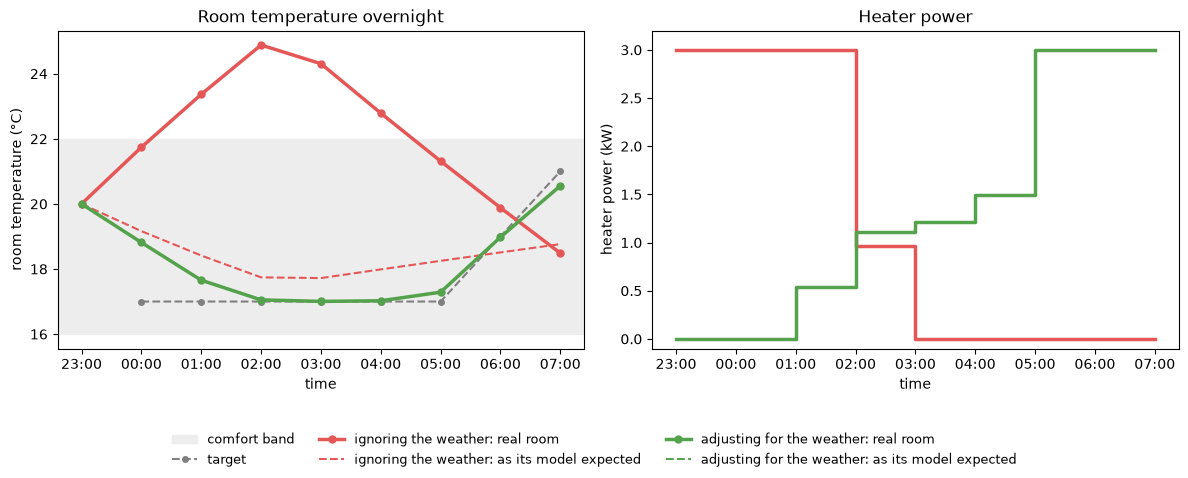

In [9]:
steps = np.arange(HORIZON + 1)
colours = {"naive": "#E45756", "causal": "#54A24B"}
fig, (ax_room, ax_power) = plt.subplots(1, 2, figsize=(12, 4.8))
ax_room.axhspan(*BAND, color="0.93", label="comfort band")
ax_room.plot(steps[1:], target, ls="--", color="0.5", marker="o", ms=4, label="target")
for key, (power, room) in played.items():
    expected = np.asarray(plans[key].plan.trajectory)[:, 0]
    ax_room.plot(
        steps, room, color=colours[key], lw=2.5, marker="o", ms=5, label=f"{labels[key]}: real room"
    )
    ax_room.plot(
        steps,
        expected,
        color=colours[key],
        lw=1.5,
        ls="--",
        label=f"{labels[key]}: as its model expected",
    )
    ax_power.step(steps, np.append(power, power[-1]), where="post", color=colours[key], lw=2.5)
ax_room.set_ylabel("room temperature (°C)")
ax_room.set_title("Room temperature overnight")
ax_power.set_ylabel("heater power (kW)")
ax_power.set_ylim(-0.1, HEATER_MAX + 0.2)
ax_power.set_title("Heater power")
for axis in (ax_room, ax_power):
    axis.set_xticks(steps, clock)
    axis.set_xlabel("time")
handles, names = ax_room.get_legend_handles_labels()
fig.legend(handles, names, loc="lower center", ncol=3, fontsize=9, frameon=False)
fig.tight_layout(rect=(0, 0.14, 1, 1))
plt.show()

The plan that ignored the weather heats at full power from 23:00. Its model says that heat brings
the room down to the set-back. The real room overheats instead, to 24.9 °C, above the band. Then
the plan switches the heater off, because its model says that lets the room warm up, and the
room falls to 18.5 °C by 07:00, 2.5 degrees short of the target. It used 10.0 kilowatt-hours
(kWh, one kilowatt for one hour), about as much as the other plan, but at the wrong time: in the
middle of the night instead of before breakfast.

The plan that adjusted for the weather lets the room cool to the set-back, holds it there and
heats hard before dawn. It stays inside the band all night and reaches 20.6 °C at 07:00, with
10.4 kWh. It ends 0.4 degrees short of the target. The heater already runs at full power for the
last two hours. To warm the room sooner, the plan would miss the 17 °C target at 05:00 by more,
so it weighs one miss against the other. The price on heating adds a little to the gap.

The dashed lines are what each model expected. The second model's forecast lies on top of what
the room really did. The first model's forecast is nowhere near it.

## 5 · How far to trust the plan

Beside each plan, `prescribe` returns a **certificate**. It answers two separate questions:

- **Identification**: do the logs and the graph pin down the heater's effect? `identified` means
  the graph shows how to separate the heater from everything else that moved with it.
  `asserted` means we only claimed it.
- **Trustworthy steps**: for how many hours does the plan's forecast stay within the tolerance we
  set? The library adds up, hour by hour, the worst error that the remaining uncertainty in the
  heater's effect could cause, and stops trusting the plan when that error passes the tolerance.

In [10]:
for key, prescription in plans.items():
    certificate = prescription.certificate
    print(
        f"{labels[key]:26s} identification: {certificate.identification:10s}  "
        f"trustworthy hours: {certificate.trustworthy_steps} of {HORIZON}"
    )
print(f"tolerance: {decision['tolerance']} °C")
radius = causal.certificate.identification_radius
print(f"standard error of the adjusted heater effect: {radius:.3f} °C per hour for each kW")

ignoring the weather       identification: asserted    trustworthy hours: 0 of 8
adjusting for the weather  identification: identified  trustworthy hours: 8 of 8
tolerance: 1.0 °C
standard error of the adjusted heater effect: 0.015 °C per hour for each kW


The plan that adjusted for the weather is identified, and the certificate trusts all 8 of its
hours. The certificate is cautious by design: it assumes that the error adds up in the worst
direction every hour. Here the logs pin the heater's effect down to a standard error of 0.015 °C
per hour for each kW, so even that worst case stays within the 1 °C tolerance until 07:00. The
plan that ignored the weather is only asserted. Its fit adjusted for nothing, so it reports no
error on the heater's effect and nothing bounds its forecast: the certificate trusts none of its
hours, whatever its model predicts.

**What if the outdoor temperature had never been logged?** Then nothing in the logs can
separate the weather's effect from the heater's. We say so in the graph: `outdoor` is declared
*latent*, meaning not observed, and its column is dropped from the logs. This call prints a
warning too, and that warning is expected.

In [11]:
never_logged = CausalGraph.from_edges(graph.edges, latent=("outdoor",))
blind_panel = Panel.from_frame(logs.drop(columns="outdoor"), unit="night", time="hour", seed=0)
blind = prescribe(blind_panel, adjustment=never_logged, **decision)
print(f"identification: {blind.certificate.identification}")
print(f"why: {blind.certificate.adjustment.reason}")
print(f"plan: {blind.plan}")
try:
    blind.schedule
except NotIdentifiedError as error:
    print(f"asking for the schedule raises NotIdentifiedError: {error}")

no schedule: no observed set identifies the effect


identification: not_identified
why: no observed set blocks every non-causal path; latent ['outdoor'] confounds it
plan: None
asking for the schedule raises NotIdentifiedError: the effect is not identified, so no schedule was computed: no observed set blocks every non-causal path; latent ['outdoor'] confounds it


The certificate says `not_identified` and names the reason: the latent outdoor temperature.
No plan at all, and on purpose. Any schedule here would rest on a heater effect that the logs
cannot separate from the weather. Section 3 showed how wrong such an effect can be: it had the
wrong sign, and section 4 showed the plan built on it heating the house at midnight and leaving
it cold at breakfast. Refusing is the honest answer. The fix is more information, not a cleverer
fit: log the outdoor temperature, or let the heater vary at random for a while so that its
effect shows apart from the weather.

## Takeaways

- Logs from a controller that reacted to the weather mix the heater's effect with the weather's.
  A model fitted on them alone can get even the sign of the effect wrong, and its plan then does
  the opposite of what the room needs.
- Telling `prescribe` what caused what, with a causal graph, and what tonight's weather will be,
  with a `Driver`, recovers the true effect and a plan that keeps the room inside the comfort
  band.
- Read the certificate before the plan. Identification says whether the effect is pinned down;
  trustworthy steps say for how many hours the forecast holds.
- When the confounder was never logged, `prescribe` returns no plan rather than a confident wrong
  one.